# This script runs the Example 1 on OpenTRIM (`opentrim`) from a Python notebook

In this notebook we create the configuration for example 1 and run it through Python.


It assumes `opentrim` is available on your `PATH`. If it is not, set `exe`
to the full path (example in the comment below).

In [40]:
from copy import deepcopy  # used to clone the JSON template dict so edits won't mutate the original
from pathlib import Path   # convenient, cross-platform path handling (files, joining paths, etc.)
import json                # encode/decode JSON (opentrim -t output, writing config.json)

import subprocess          # run the external `opentrim` executable and capture stdout/stderr
import tempfile            # create a temporary directory to run opentrim without polluting your repo

from typing import Any, Dict  # type hints for config dictionaries, helps readability in notebooks

import h5py                # read the HDF5 output file produced by opentrim (result.h5)
import numpy as np         # convert datasets to NumPy arrays, manipulate/flatten/slice for plotting
import matplotlib.pyplot as plt  # plot results from datasets using Matplotlib

The code below generates the template json file.

In [41]:
exe = "opentrim"
cmd_template = [exe, "-t"]

template_run = subprocess.run(
    cmd_template,
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    timeout=20,
)

template_run.check_returncode()  # raises if opentrim -t failed
json_template: Dict[str, Any] = json.loads(template_run.stdout)

# Start Config from the template
Config: Dict[str, Any] = deepcopy(json_template)

## Customize the Config in the code below:

In [42]:
# Example edits:
Config["Transport"]["flight_path_type"] = "Variable"

Config["IonBeam"]["ion"]["atomic_mass"] = 1.00784
Config["IonBeam"]["energy_distribution"]["center"] = 1000000.0
Config["IonBeam"]["spatial_distribution"]["center"] = [
                0.0,
                5000.0,
                5000.0]
Config["Target"]["size"] = [
            10000.0,
            10000.0,
            10000.0
        ]
Config["Target"]["cell_count"] = [
            100,
            1,
            1
        ]
Config["Target"]["materials"][0]["id"] = "Fe"
Config["Target"]["materials"][0]["composition"][0]["Es"] = 3.0
Config["Target"]["regions"][0]["material_id"] = "Fe"
Config["Target"]["regions"][0]["size"] = [
            10000.0,
            10000.0,
            10000.0
        ]
Config["Output"]["title"] = "1 MeV H on Fe example"
Config["Output"]["outfilename"] = "Example1"
Config["Output"]["store_exit_events"] = True
Config["Output"]["store_pka_events"] = True

Config["Run"]["threads"] = 4
Config["Run"]["max_no_ions"] = 20000

Config["UserTally"] = [] # otherwise it crashes

Below are the functions that generate the JSON file:

In [43]:
config_path = Path("config.json").resolve()
config_path.write_text(json.dumps(Config, indent=4) + "\n", encoding="utf-8")
print("Wrote:", config_path)

Wrote: /home/yiannis/dimokritos/my-fork/OpenTRIM/test/python/config.json


If your PATH is set up correctly, this is enough:

returncode: 0
stdout:
 Parsing JSON config from config.json
Starting simulation '1 MeV H on Fe example'...


║                                        ║  0%║ETC 00:00:00║
║█████████████▉                          ║ 34%║ETC 00:00:01║
║████████████████████████████▍           ║ 70%║ETC 00:00:01║
║████████████████████████████████████████║100%║ETC 00:00:00║
║████████████████████████████████████████║100%║ETC 00:00:00║

Completed 20000 ion histories.
Threads: 4
Cpu time (s):  2.17866,	Ions/cpu-s:  9179.95
Real time (s): 0.607166,	Ions/real-s: 32939.9
Storing results in result.h5 ... OK.

stderr:
 
h5 exists: True path: /tmp/opentrim_m_vhe_tv/result.h5

=== HDF5 contents ===
[G] events/
[G] events/exit/
[D] events/exit/column_descriptions  shape=(10,)  dtype=object
[D] events/exit/column_names  shape=(10,)  dtype=object
[D] events/exit/event_data  shape=(1, 10)  dtype=float32
[G] events/pka/
[D] events/pka/column_descriptions  shape=(11,)  dtype=object
[D] events/pka/column_names  shape=(11,)  d

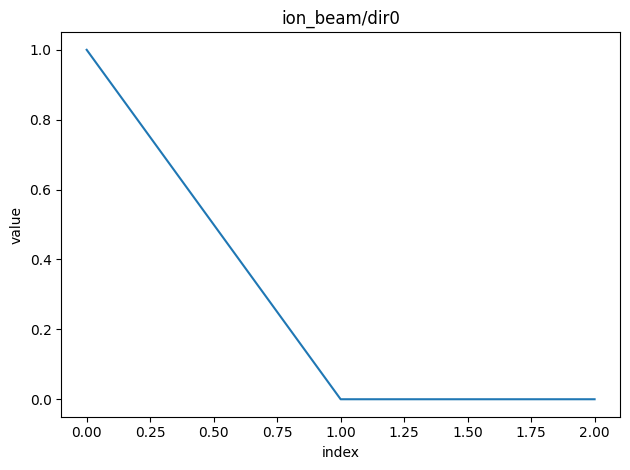

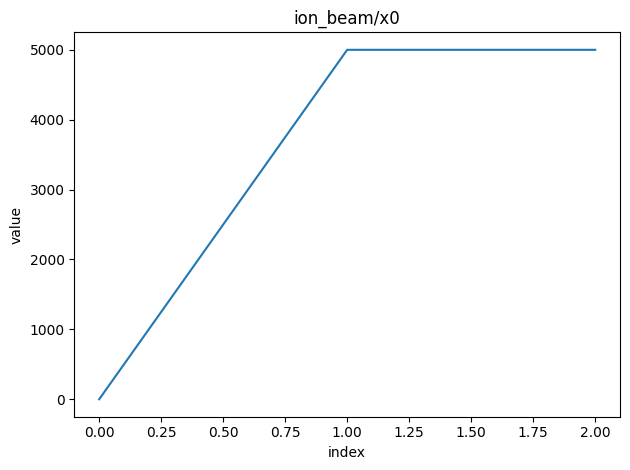

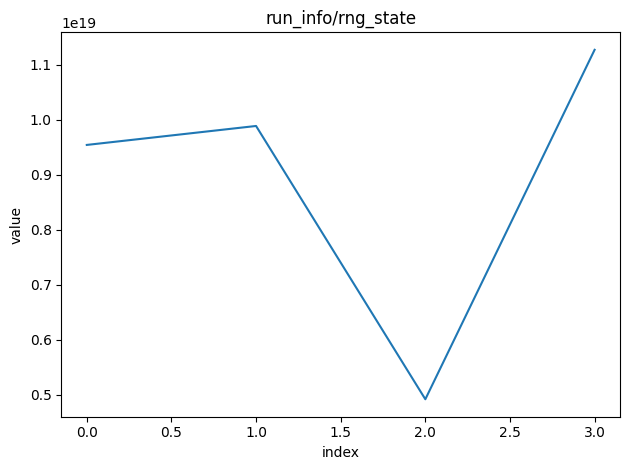

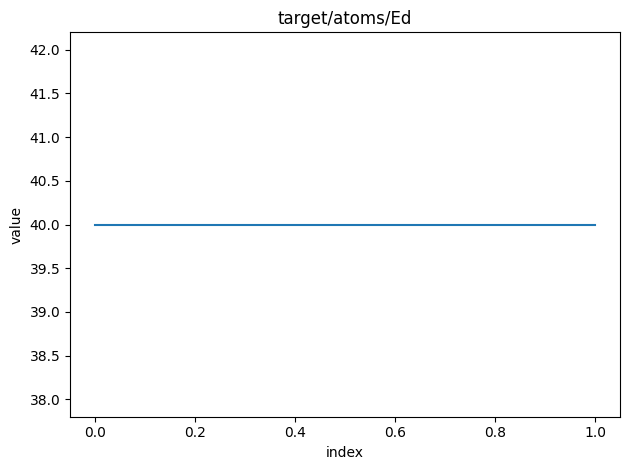

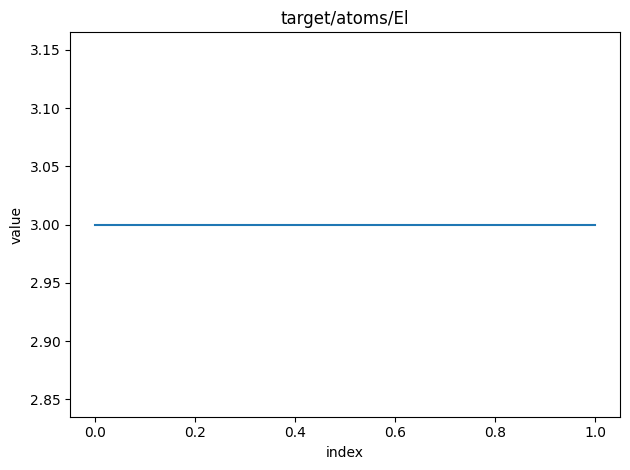

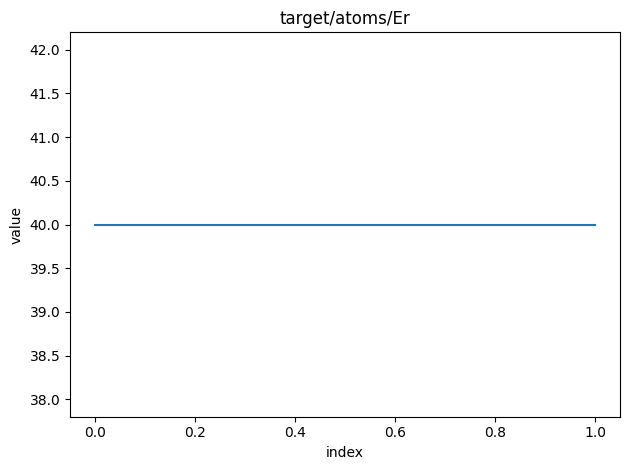

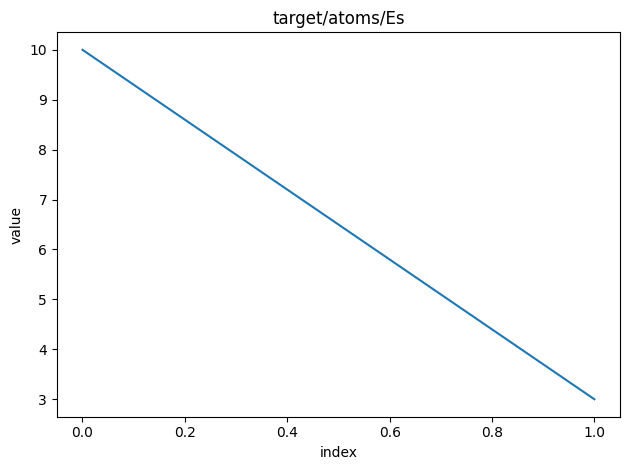

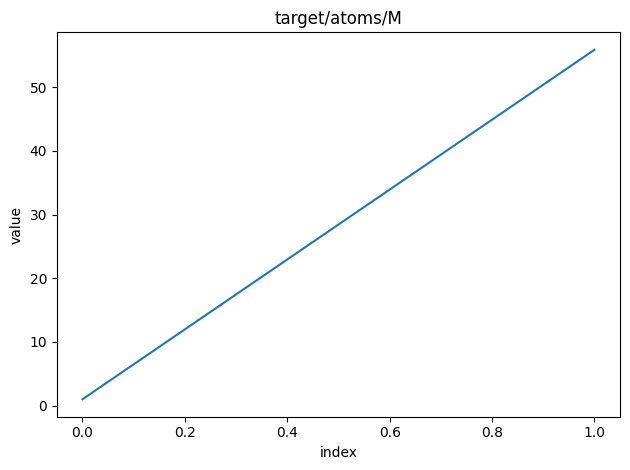

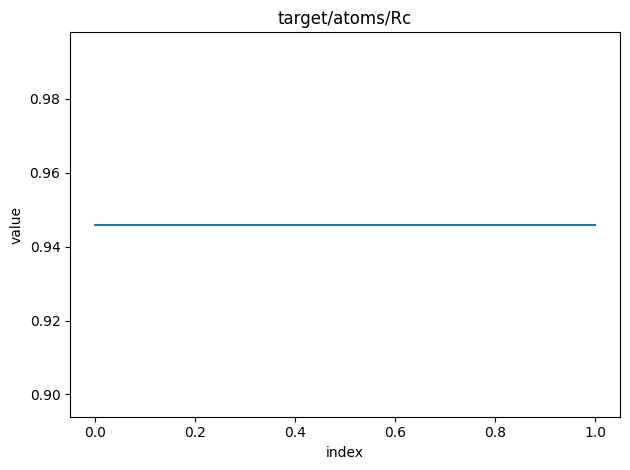

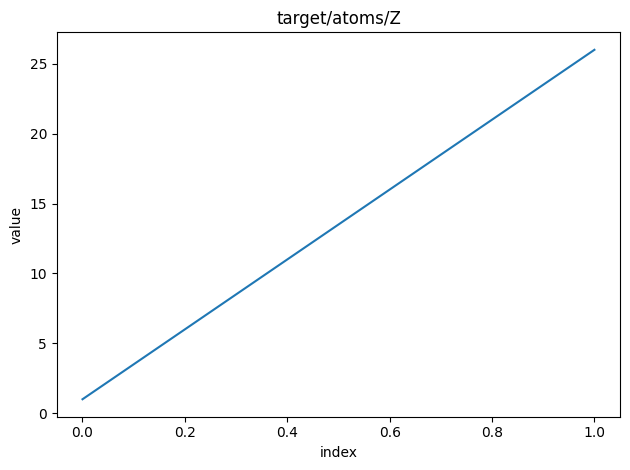

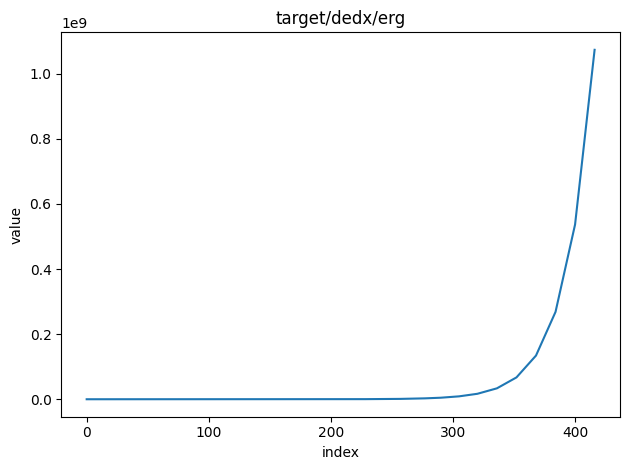

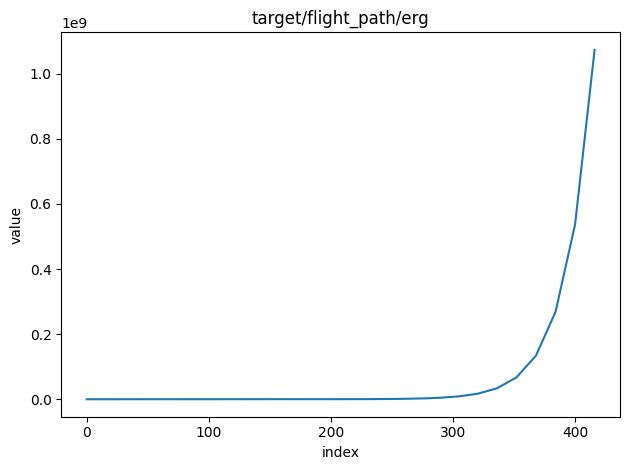

Plotted 12 dataset(s).


In [44]:
def list_h5(h5file: h5py.File) -> None:
    """
    Print a simple tree of the HDF5 file contents.

    Why this exists:
      - opentrim writes many datasets/groups and their names can change between versions.
      - Listing the structure makes it easy to discover what you can plot (dataset paths, shapes, dtypes).
    """
    def visitor(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(f"[D] {name}  shape={obj.shape}  dtype={obj.dtype}")
        elif isinstance(obj, h5py.Group):
            print(f"[G] {name}/")

    h5file.visititems(visitor)


def plot_dataset(arr: np.ndarray, *, title: str = "") -> None:
    """
    Plot a numeric dataset in a generic way.

    Why this exists:
      - In a notebook, you often just want a quick visualization without writing custom plotting code.
      - Handles common cases:
          * 1D arrays -> line plot
          * 2D arrays -> heatmap (imshow)
      - For other shapes, it prints a message rather than failing.
    """
    plt.figure()

    if arr.ndim == 1:
        plt.plot(arr)
        plt.xlabel("index")
        plt.ylabel("value")

    elif arr.ndim == 2:
        plt.imshow(arr, aspect="auto", origin="lower")
        plt.colorbar(label="value")
        plt.xlabel("x index")
        plt.ylabel("y index")

    else:
        plt.text(0.5, 0.5, f"Can't auto-plot shape {arr.shape}", ha="center", va="center")
        plt.axis("off")

    plt.title(title or f"shape={arr.shape}")
    plt.tight_layout()
    plt.show()


def plot_all_1d_numeric(h5file: h5py.File, *, max_plots: int = 12) -> None:
    """
    Plot up to `max_plots` 1D numeric datasets found anywhere in the file.

    Why this exists:
      - It's a fast way to "see something" after a run, without knowing the file structure beforehand.
      - It only plots 1D datasets because:
          * they're usually meaningful curves
          * they're cheap to render
          * it avoids accidentally plotting huge multidimensional tensors
    """
    plotted = 0

    def visitor(name, obj):
        nonlocal plotted
        if plotted >= max_plots:
            return

        if (
            isinstance(obj, h5py.Dataset)
            and obj.dtype.kind in ("i", "u", "f")   # integer/unsigned/float
            and obj.ndim == 1
            and obj.size > 0
        ):
            arr = np.asarray(obj[...])
            plot_dataset(arr, title=name)
            plotted += 1

    h5file.visititems(visitor)

    if plotted == 0:
        print("No 1D numeric datasets found to plot.")
    else:
        print(f"Plotted {plotted} dataset(s).")


# --- Run opentrim in an isolated temp directory, then read+plot while it still exists ---
with tempfile.TemporaryDirectory(prefix="opentrim_") as tmp:
    tmpdir = Path(tmp)

    # Write the JSON config inside the temp directory.
    # Why: keeps generated files out of your git repo and avoids path confusion in notebooks.
    config_path = tmpdir / "config.json"
    config_path.write_text(json.dumps(Config, indent=4) + "\n", encoding="utf-8")

    # opentrim uses "-o <base>" and produces "<base>.h5"
    out_base = "result"
    h5_path = tmpdir / f"{out_base}.h5"

    # Run opentrim with cwd=tmpdir so it can find config.json by name
    cmd = [exe, "-f", "config.json", "-o", out_base, "-s", "42"]
    result = subprocess.run(
        cmd,
        cwd=str(tmpdir),
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        timeout=120,
    )

    # Show what happened (very useful in notebooks)
    print("returncode:", result.returncode)
    print("stdout:\n", result.stdout)
    print("stderr:\n", result.stderr)

    print("h5 exists:", h5_path.exists(), "path:", h5_path)

    # IMPORTANT: open + plot the H5 file *inside* the TemporaryDirectory context.
    # Otherwise the temp dir will be deleted and you'll get FileNotFoundError.
    if not h5_path.exists():
        raise FileNotFoundError(f"opentrim did not produce an H5 file at: {h5_path}")

    with h5py.File(h5_path, "r") as f:
        print("\n=== HDF5 contents ===")
        list_h5(f)

        print("\n=== Plotting 1D numeric datasets (first few) ===")
        plot_all_1d_numeric(f, max_plots=12)